**Tugas Individu Coding 2 - Fazari Razka Davira**

In [1]:
!pip install -q split-folders timm grad-cam

import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, datasets, transforms
from torch.utils.data import DataLoader
import timm
import cv2
import numpy as np
import shutil
import glob
import splitfolders
import matplotlib.pyplot as plt
from PIL import Image
import copy
import time
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
import seaborn as sns
import random
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

device = torch.device("cpu")
print(f"Menggunakan device: {device}")

Menggunakan device: cpu


In [2]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    is_colab = True
except ImportError:
    print('Running locally, skipping Google Drive mount')
    is_colab = False


Running locally, skipping Google Drive mount


In [3]:
if is_colab:
    base_path = '/content/drive/MyDrive'
    path_zip_kaggle = f'{base_path}/busi-kaggle.zip'
    path_zip_mendeley = f'{base_path}/busi-mendeley.zip'
else:
    # Local paths (placeholders as we will skip extraction)
    base_path = '../Dataset'
    path_zip_kaggle = ''
    path_zip_mendeley = ''

target_kaggle   = 'dataset_kaggle'
target_mendeley   = 'dataset_mendeley'

print("=== MEMPROSES DATASET ===")
if is_colab:
    if os.path.exists(path_zip_kaggle):
        !unzip -q "{path_zip_kaggle}" -d "{target_kaggle}"
    if os.path.exists(path_zip_mendeley):
        !unzip -q "{path_zip_mendeley}" -d "{target_mendeley}"
else:
    print("Mode Lokal: Melewati ekstraksi zip (Dataset diasumsikan sudah ada)")


=== MEMPROSES DATASET ===
Mode Lokal: Melewati ekstraksi zip (Dataset diasumsikan sudah ada)


In [4]:
path_kaggle = "dataset_kaggle/Dataset_BUSI_with_GT"
path_mendeley_root = "dataset_mendeley"

# Output Path Logic
if is_colab:
    output_path = "dataset_gabungan"
    if not os.path.exists(output_path):
        os.makedirs(output_path)
    classes = ['benign', 'malignant', 'normal']
    for c in classes:
        os.makedirs(os.path.join(output_path, c), exist_ok=True)
else:
    output_path = "../Dataset"
    print(f"Mode Lokal: output_path set to {output_path}")

# Function Definitions (Always define to safely skip)
def smart_merge_mendeley(root_folder, output_root):
    count_benign = 0
    count_malig = 0

    all_files = []
    for ext in ['*.png', '*.jpg', '*.jpeg', '*.bmp']:
        all_files.extend(glob.glob(os.path.join(root_folder, '**', ext), recursive=True))

    for f in all_files:
        filename = os.path.basename(f).lower()

        target_class = None
        if 'benign' in filename:
            target_class = 'benign'
            count_benign += 1
        elif 'malignant' in filename:
            target_class = 'malignant'
            count_malig += 1
        else:
            parent_folder = os.path.basename(os.path.dirname(f)).lower()
            if 'benign' in parent_folder:
                target_class = 'benign'
                count_benign += 1
            elif 'malignant' in parent_folder:
                target_class = 'malignant'
                count_malig += 1

        if target_class:
            dest_name = f"mendeley_{filename}"
            dest_path = os.path.join(output_root, target_class, dest_name)
            shutil.copy(f, dest_path)

    return count_benign, count_malig

def copy_kaggle_simple(src, cls, dst):
    files = glob.glob(os.path.join(src, cls, '*.*'))
    cnt = 0
    for f in files:
        if 'mask' not in os.path.basename(f):
            shutil.copy(f, os.path.join(dst, cls, f"kaggle_{os.path.basename(f)}"))
            cnt += 1
    return cnt

print("=== MULAI MERGE DATASET ===")

if is_colab:
    print("Copying Kaggle Data...")
    k_benign = copy_kaggle_simple(path_kaggle, 'benign', output_path)
    k_malig = copy_kaggle_simple(path_kaggle, 'malignant', output_path)
    k_normal = copy_kaggle_simple(path_kaggle, 'normal', output_path)

    print("Copying Mendeley Data...")
    m_benign, m_malig = smart_merge_mendeley(path_mendeley_root, output_path)
else:
    print("Mode Lokal: Melewati proses merge (Dataset diasumsikan sudah siap/merged).")
    k_benign, k_malig, k_normal = 0, 0, 0
    m_benign, m_malig = 0, 0

print("\n" + "="*40)
print(f"HASIL AKHIR PENGGABUNGAN:")
print(f"Benign   : {k_benign} (Kaggle) + {m_benign} (Mendeley) = {k_benign + m_benign}")
print(f"Malignant: {k_malig} (Kaggle) + {m_malig} (Mendeley) = {k_malig + m_malig}")
print(f"Normal   : {k_normal} (Kaggle) + 0 = {k_normal}")
print("="*40)

# Splitting
if is_colab:
    if os.path.exists("dataset_split"):
        shutil.rmtree("dataset_split")

print("Sedang membagi dataset (Splitting)...")
# output_path points to ../Dataset if local, so splitfolders works on that
splitfolders.ratio(output_path, output="dataset_split", seed=42, ratio=(.7, .15, .15), group_prefix=None) # Split Dataset (Train 70%, Val 15%, Test 15%)
print("Selesai! Dataset siap di folder 'dataset_split'")

Mode Lokal: output_path set to ../Dataset
=== MULAI MERGE DATASET ===
Mode Lokal: Melewati proses merge (Dataset diasumsikan sudah siap/merged).

HASIL AKHIR PENGGABUNGAN:
Benign   : 0 (Kaggle) + 0 (Mendeley) = 0
Malignant: 0 (Kaggle) + 0 (Mendeley) = 0
Normal   : 0 (Kaggle) + 0 = 0
Sedang membagi dataset (Splitting)...


Copying files: 1030 files [00:00, 5817.59 files/s]

Selesai! Dataset siap di folder 'dataset_split'


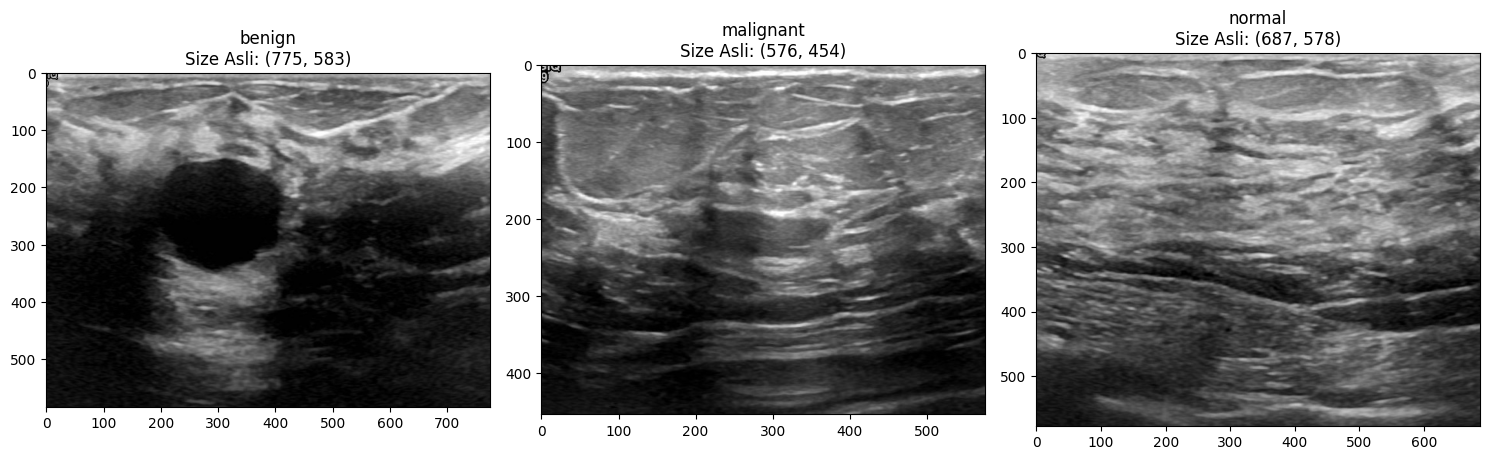

In [5]:
def show_raw_images(dataset_path, num_images=3):

    classes = ['benign', 'malignant', 'normal']

    plt.figure(figsize=(15, 5))

    for i, cls in enumerate(classes):
        class_folder = os.path.join(dataset_path, 'train', cls)
        random_img = random.choice(os.listdir(class_folder))
        img_path = os.path.join(class_folder, random_img)

        img = Image.open(img_path)

        plt.subplot(1, 3, i+1)
        plt.imshow(img, cmap='gray')
        plt.title(f"{cls}\nSize Asli: {img.size}")
        plt.axis('on')

    plt.tight_layout()
    plt.show()

show_raw_images('dataset_split')

--- Training DenseNet121 (Raw Data) ---
Ep 1: Val Acc: 0.7778
Ep 2: Val Acc: 0.8562
Ep 3: Val Acc: 0.8235
Ep 4: Val Acc: 0.8693
Ep 5: Val Acc: 0.8562
Ep 6: Val Acc: 0.8301
Ep 7: Val Acc: 0.8366
Ep 8: Val Acc: 0.8627
Ep 9: Val Acc: 0.8431
Ep 10: Val Acc: 0.8693
--- Training Xception (Raw Data) ---


/home/habb/Kuliah/HUMIC/Integrated-AI/vhumic/lib/python3.12/site-packages/timm/models/_factory.py:138: UserWarning: Mapping deprecated model name xception to current legacy_xception.
  model = create_fn(


Ep 1: Val Acc: 0.6078
Ep 2: Val Acc: 0.8301
Ep 3: Val Acc: 0.8301
Ep 4: Val Acc: 0.8497
Ep 5: Val Acc: 0.8301
Ep 6: Val Acc: 0.8431
Ep 7: Val Acc: 0.8301
Ep 8: Val Acc: 0.8301
Ep 9: Val Acc: 0.8105
Ep 10: Val Acc: 0.8235


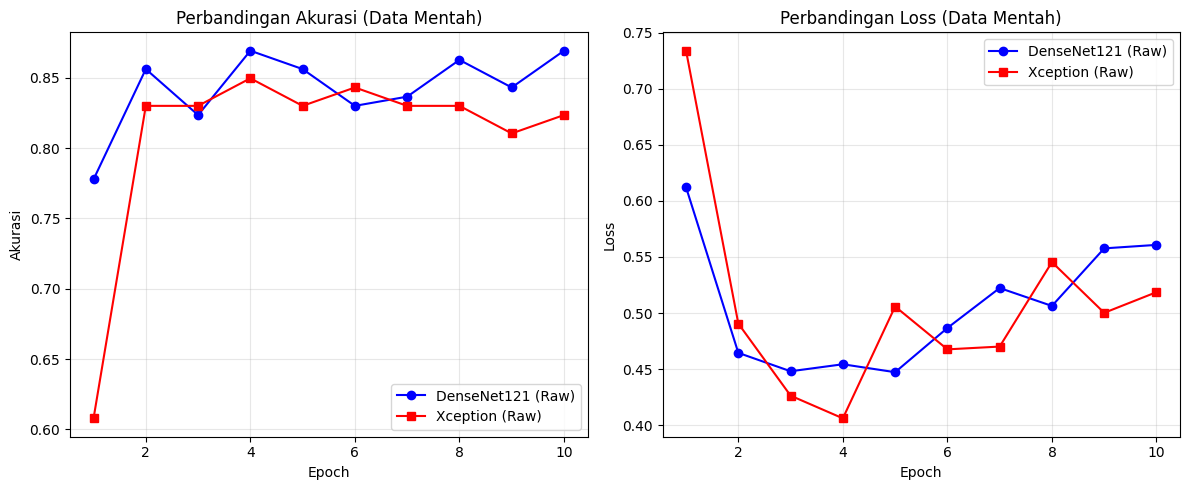

In [6]:
transform_raw = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

data_dir = 'dataset_split'
BATCH = 32

train_set_raw = datasets.ImageFolder(os.path.join(data_dir, 'train'), transform=transform_raw)
val_set_raw   = datasets.ImageFolder(os.path.join(data_dir, 'val'), transform=transform_raw)
test_set_raw  = datasets.ImageFolder(os.path.join(data_dir, 'test'), transform=transform_raw)

loader_raw = {
    'train': DataLoader(train_set_raw, batch_size=BATCH, shuffle=True),
    'val': DataLoader(val_set_raw, batch_size=BATCH, shuffle=False),
    'test': DataLoader(test_set_raw, batch_size=1, shuffle=False)
}

def train_quick(model, name, epochs=10):
    print(f"--- Training {name} (Raw Data) ---")
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.0001)

    history = {'acc': [], 'loss': []}

    for epoch in range(epochs):
        model.train()
        for inputs, labels in loader_raw['train']:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

        model.eval()
        val_loss, val_corrects = 0.0, 0
        with torch.no_grad():
            for inputs, labels in loader_raw['val']:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                _, preds = torch.max(outputs, 1)
                val_loss += loss.item() * inputs.size(0)
                val_corrects += torch.sum(preds == labels.data)

        epoch_loss = val_loss / len(val_set_raw)
        epoch_acc = val_corrects.double() / len(val_set_raw)

        history['acc'].append(epoch_acc.item())
        history['loss'].append(epoch_loss)
        print(f"Ep {epoch+1}: Val Acc: {epoch_acc:.4f}")

    return model, history

# A. DenseNet121
dense_base = models.densenet121(weights='DEFAULT')
dense_base.classifier = nn.Linear(1024, 3)
model_dense_raw, hist_dense_raw = train_quick(dense_base, "DenseNet121")

# B. Xception
xcp_base = timm.create_model('xception', pretrained=True)
xcp_base.fc = nn.Linear(2048, 3)
model_xcp_raw, hist_xcp_raw = train_quick(xcp_base, "Xception")

epochs = range(1, 11)
plt.figure(figsize=(12, 5))

# Plot Akurasi
plt.subplot(1, 2, 1)
plt.plot(epochs, hist_dense_raw['acc'], 'b-o', label='DenseNet121 (Raw)')
plt.plot(epochs, hist_xcp_raw['acc'], 'r-s', label='Xception (Raw)')
plt.title('Perbandingan Akurasi (Data Mentah)')
plt.xlabel('Epoch'); plt.ylabel('Akurasi')
plt.legend(); plt.grid(True, alpha=0.3)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs, hist_dense_raw['loss'], 'b-o', label='DenseNet121 (Raw)')
plt.plot(epochs, hist_xcp_raw['loss'], 'r-s', label='Xception (Raw)')
plt.title('Perbandingan Loss (Data Mentah)')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.legend(); plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

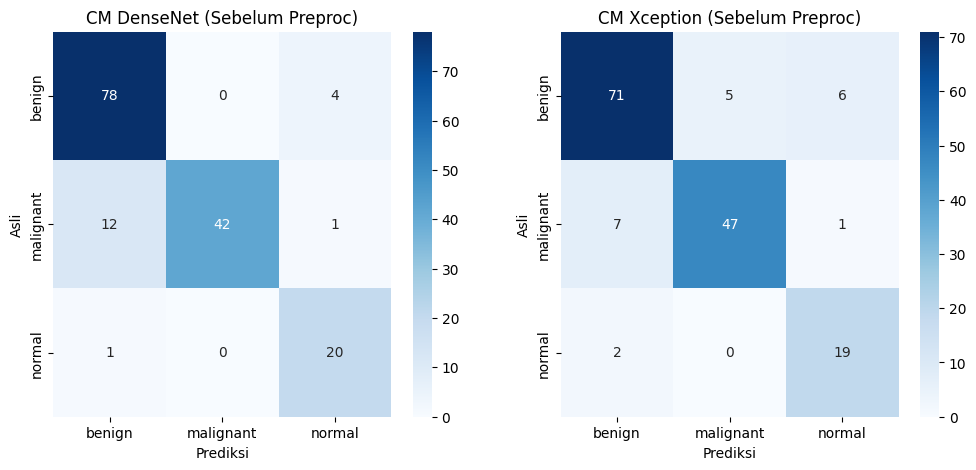

In [7]:
def show_cm(model, title, ax):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for inputs, labels in loader_raw['test']:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=train_set_raw.classes, yticklabels=train_set_raw.classes)
    ax.set_title(title); ax.set_ylabel('Asli'); ax.set_xlabel('Prediksi')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
show_cm(model_dense_raw, "CM DenseNet (Sebelum Preproc)", axes[0])
show_cm(model_xcp_raw, "CM Xception (Sebelum Preproc)", axes[1])
plt.show()

In [8]:
class UltrasoundEnhancement(object):
    def __init__(self, apply_clahe=True, apply_denoise=True):
        self.apply_clahe = apply_clahe
        self.apply_denoise = apply_denoise

    def __call__(self, img):
        img_np = np.array(img.convert('L'))

        if self.apply_denoise:
            img_np = cv2.medianBlur(img_np, 5)

        if self.apply_clahe:
            clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
            img_np = clahe.apply(img_np)

        img_rgb = cv2.cvtColor(img_np, cv2.COLOR_GRAY2RGB)

        return Image.fromarray(img_rgb)

print("Class UltrasoundEnhancement berhasil dibuat!")

Class UltrasoundEnhancement berhasil dibuat!


In [9]:
transform_dense_train = transforms.Compose([
    UltrasoundEnhancement(apply_clahe=True, apply_denoise=True),
    transforms.Resize((224, 224)),
    transforms.RandomRotation(15),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

transform_dense_val = transforms.Compose([
    UltrasoundEnhancement(apply_clahe=True, apply_denoise=True),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

transform_xcp_train = transforms.Compose([
    UltrasoundEnhancement(apply_clahe=True, apply_denoise=True),
    transforms.Resize((320, 320)),
    transforms.CenterCrop(299),
    transforms.RandomRotation(15),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

transform_xcp_val = transforms.Compose([
    UltrasoundEnhancement(apply_clahe=True, apply_denoise=True),
    transforms.Resize((320, 320)),
    transforms.CenterCrop(299),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

data_dir = 'dataset_split'
batch_size = 32

train_set_dense = datasets.ImageFolder(os.path.join(data_dir, 'train'), transform=transform_dense_train)
val_set_dense   = datasets.ImageFolder(os.path.join(data_dir, 'val'), transform=transform_dense_val)
test_set_dense  = datasets.ImageFolder(os.path.join(data_dir, 'test'), transform=transform_dense_val)

train_loader_dense = DataLoader(train_set_dense, batch_size=batch_size, shuffle=True)
val_loader_dense   = DataLoader(val_set_dense, batch_size=batch_size, shuffle=False)
test_loader_dense  = DataLoader(test_set_dense, batch_size=1, shuffle=False)

train_set_xcp = datasets.ImageFolder(os.path.join(data_dir, 'train'), transform=transform_xcp_train)
val_set_xcp   = datasets.ImageFolder(os.path.join(data_dir, 'val'), transform=transform_xcp_val)
test_set_xcp  = datasets.ImageFolder(os.path.join(data_dir, 'test'), transform=transform_xcp_val)

train_loader_xcp = DataLoader(train_set_xcp, batch_size=batch_size, shuffle=True)
val_loader_xcp   = DataLoader(val_set_xcp, batch_size=batch_size, shuffle=False)
test_loader_xcp  = DataLoader(test_set_xcp, batch_size=1, shuffle=False)

loader_d = {
    'train': train_loader_dense,
    'val': val_loader_dense,
    'test': test_loader_dense
}

loader_x = {
    'train': train_loader_xcp,
    'val': val_loader_xcp,
    'test': test_loader_xcp
}

print(f"\nJumlah Kelas     : {len(train_set_dense.classes)} -> {train_set_dense.classes}")
print("-" * 40)
print(f"DenseNet Train   : {len(train_set_dense)} gambar ({len(train_loader_dense)} batches)")
print(f"Xception Train   : {len(train_set_xcp)} gambar ({len(train_loader_xcp)} batches)")
print("-" * 40)


Jumlah Kelas     : 3 -> ['benign', 'malignant', 'normal']
----------------------------------------
DenseNet Train   : 719 gambar (23 batches)
Xception Train   : 719 gambar (23 batches)
----------------------------------------


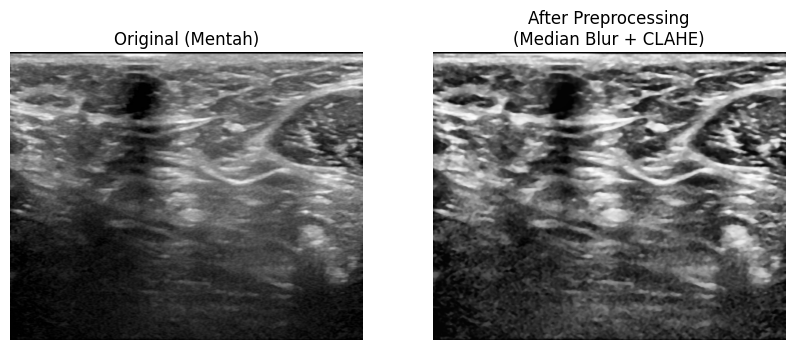

In [10]:
def show_comparison(dataset_path):
    classes = os.listdir(os.path.join(dataset_path, 'train'))
    sample_class = classes[0]
    sample_folder = os.path.join(dataset_path, 'train', sample_class)
    sample_image_path = os.path.join(sample_folder, os.listdir(sample_folder)[0])

    img_original = Image.open(sample_image_path)

    preprocessor = UltrasoundEnhancement(apply_clahe=True, apply_denoise=True)
    img_processed = preprocessor(img_original)

    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(img_original, cmap='gray')
    plt.title("Original (Mentah)")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(img_processed)
    plt.title("After Preprocessing\n(Median Blur + CLAHE)")
    plt.axis('off')

    plt.show()

show_comparison('dataset_split')

In [11]:
def get_model(model_name, num_classes):
    if model_name == 'densenet':
        model = models.densenet121(weights='DEFAULT')
        in_features = model.classifier.in_features
        model.classifier = nn.Linear(in_features, num_classes)
    elif model_name == 'xception':
        model = timm.create_model('xception', pretrained=True)
        in_features = model.get_classifier().in_features
        model.fc = nn.Linear(in_features, num_classes)
    return model.to(device)

def train_model(model, loaders, criterion, optimizer, num_epochs=10, save_name="best.pth"):
    best_acc = 0.0
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    print(f"Mulai Training {save_name}...")
    for epoch in range(num_epochs):
        for phase in ['train', 'val']:
            if phase == 'train': model.train()
            else: model.eval()

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in loaders[phase]:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                    _, preds = torch.max(outputs, 1)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / len(loaders[phase].dataset)
            epoch_acc = running_corrects.double() / len(loaders[phase].dataset)

            history[f'{phase}_loss'].append(epoch_loss)
            history[f'{phase}_acc'].append(epoch_acc.item())

            if phase == 'val':
                print(f"Epoch {epoch+1}/{num_epochs} - Val Acc: {epoch_acc:.4f}")
                if epoch_acc > best_acc:
                    best_acc = epoch_acc
                    torch.save(model.state_dict(), save_name)

    print(f"Selesai. Best Acc: {best_acc:.4f}")
    return history

In [12]:
criterion = nn.CrossEntropyLoss()
NUM_EPOCHS = 20

print("\n=== TRAIN DENSENET121 ===")
model_dense = get_model('densenet', 3)
opt_dense = optim.Adam(model_dense.parameters(), lr=0.0001)
hist_dense = train_model(model_dense, loader_d, criterion, opt_dense, NUM_EPOCHS, "best_densenet.pth")

print("\n=== TRAIN XCEPTION ===")
model_xcp = get_model('xception', 3)
opt_xcp = optim.Adam(model_xcp.parameters(), lr=0.0001)
hist_xcp = train_model(model_xcp, loader_x, criterion, opt_xcp, NUM_EPOCHS, "best_xception.pth")


=== TRAIN DENSENET121 ===
Mulai Training best_densenet.pth...
Epoch 1/20 - Val Acc: 0.6601
Epoch 2/20 - Val Acc: 0.7255
Epoch 3/20 - Val Acc: 0.8105
Epoch 4/20 - Val Acc: 0.8235
Epoch 5/20 - Val Acc: 0.8497
Epoch 6/20 - Val Acc: 0.8758
Epoch 7/20 - Val Acc: 0.8824
Epoch 8/20 - Val Acc: 0.8431
Epoch 9/20 - Val Acc: 0.8235
Epoch 10/20 - Val Acc: 0.8366
Epoch 11/20 - Val Acc: 0.8301
Epoch 12/20 - Val Acc: 0.8497
Epoch 13/20 - Val Acc: 0.8627
Epoch 14/20 - Val Acc: 0.8562
Epoch 15/20 - Val Acc: 0.8562
Epoch 16/20 - Val Acc: 0.8431
Epoch 17/20 - Val Acc: 0.8562
Epoch 18/20 - Val Acc: 0.8824
Epoch 19/20 - Val Acc: 0.8497
Epoch 20/20 - Val Acc: 0.8627
Selesai. Best Acc: 0.8824

=== TRAIN XCEPTION ===
Mulai Training best_xception.pth...


/home/habb/Kuliah/HUMIC/Integrated-AI/vhumic/lib/python3.12/site-packages/timm/models/_factory.py:138: UserWarning: Mapping deprecated model name xception to current legacy_xception.
  model = create_fn(


Epoch 1/20 - Val Acc: 0.5817
Epoch 2/20 - Val Acc: 0.6209
Epoch 3/20 - Val Acc: 0.8039
Epoch 4/20 - Val Acc: 0.8235
Epoch 5/20 - Val Acc: 0.8889
Epoch 6/20 - Val Acc: 0.8366
Epoch 7/20 - Val Acc: 0.8627
Epoch 8/20 - Val Acc: 0.8562
Epoch 9/20 - Val Acc: 0.8497
Epoch 10/20 - Val Acc: 0.8758
Epoch 11/20 - Val Acc: 0.8758
Epoch 12/20 - Val Acc: 0.8889
Epoch 13/20 - Val Acc: 0.8301
Epoch 14/20 - Val Acc: 0.8366
Epoch 15/20 - Val Acc: 0.8758
Epoch 16/20 - Val Acc: 0.9020
Epoch 17/20 - Val Acc: 0.8824
Epoch 18/20 - Val Acc: 0.9020
Epoch 19/20 - Val Acc: 0.8889
Epoch 20/20 - Val Acc: 0.8954
Selesai. Best Acc: 0.9020



=== PERBANDINGAN 1: AKURASI VALIDASI ===


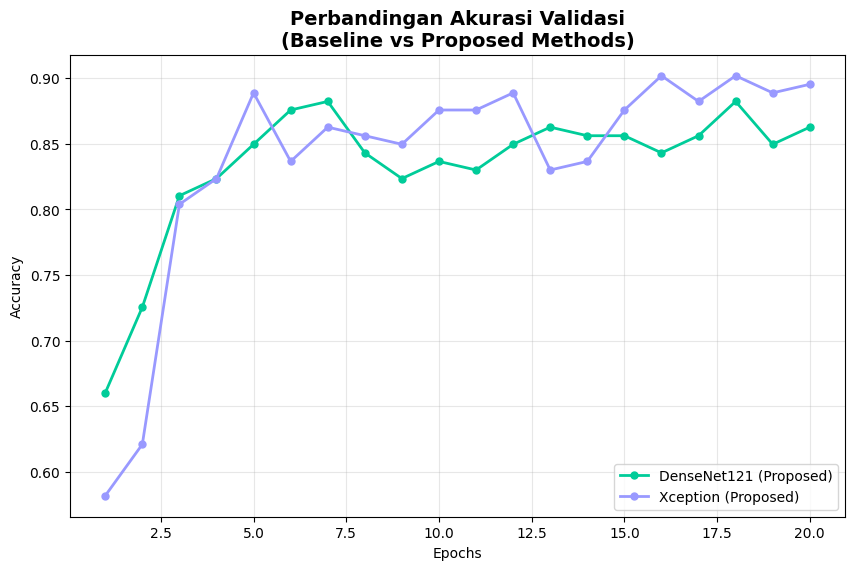


=== PERBANDINGAN 2: VALIDATION LOSS ===


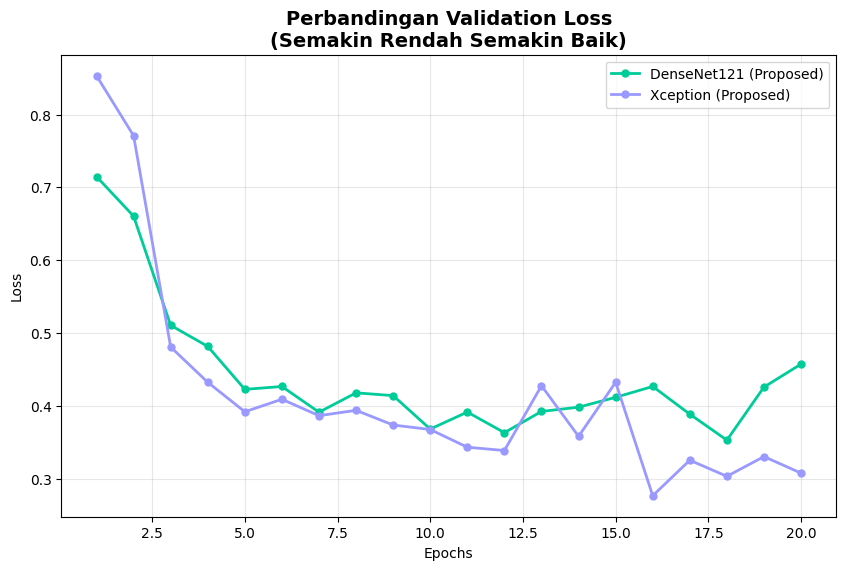

In [13]:
def plot_comparison(histories, metric, title, ylabel):
    plt.figure(figsize=(10, 6))

    colors = ['#FF9999', '#00CC99', '#9999FF']
    markers = ['--', '-', '-']

    for i, (name, history) in enumerate(histories.items()):
        if history is None:
            print(f"Warning: Data history untuk {name} tidak ditemukan. Skip.")
            continue

        val = history[metric]
        epochs = range(1, len(val) + 1)

        plt.plot(epochs, val, linestyle=markers[i%3], color=colors[i%3],
                 linewidth=2, marker='o', markersize=5, label=name)

    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel('Epochs')
    plt.ylabel(ylabel)
    plt.legend(loc='best')
    plt.grid(True, alpha=0.3)
    plt.show()

models_history = {
    'Baseline (No Preproc)': history_base if 'history_base' in locals() else None,
    'DenseNet121 (Proposed)': hist_dense if 'hist_dense' in locals() else None,
    'Xception (Proposed)': hist_xcp if 'hist_xcp' in locals() else None
}

print("\n=== PERBANDINGAN 1: AKURASI VALIDASI ===")
plot_comparison(
    models_history,
    metric='val_acc',
    title='Perbandingan Akurasi Validasi\n(Baseline vs Proposed Methods)',
    ylabel='Accuracy'
)

print("\n=== PERBANDINGAN 2: VALIDATION LOSS ===")
plot_comparison(
    models_history,
    metric='val_loss',
    title='Perbandingan Validation Loss\n(Semakin Rendah Semakin Baik)',
    ylabel='Loss'
)


=== PERBANDINGAN PERFORMA (F1-SCORE) ===
Bobot DenseNet berhasil di-load.
--- Menguji DenseNet121 pada Test Set ---
Laporan Klasifikasi DenseNet121:
              precision    recall  f1-score   support

      benign     0.8718    0.8293    0.8500        82
   malignant     0.8462    0.8000    0.8224        55
      normal     0.7500    1.0000    0.8571        21

    accuracy                         0.8418       158
   macro avg     0.8226    0.8764    0.8432       158
weighted avg     0.8467    0.8418    0.8414       158

Accuracy: 0.8418
Weighted F1-Score: 0.8414



/home/habb/Kuliah/HUMIC/Integrated-AI/vhumic/lib/python3.12/site-packages/timm/models/_factory.py:138: UserWarning: Mapping deprecated model name xception to current legacy_xception.
  model = create_fn(


Bobot Xception berhasil di-load.
--- Menguji Xception pada Test Set ---
Laporan Klasifikasi Xception:
              precision    recall  f1-score   support

      benign     0.9059    0.9390    0.9222        82
   malignant     0.9412    0.8727    0.9057        55
      normal     0.8182    0.8571    0.8372        21

    accuracy                         0.9051       158
   macro avg     0.8884    0.8896    0.8883       158
weighted avg     0.9065    0.9051    0.9051       158

Accuracy: 0.9051
Weighted F1-Score: 0.9051

SKOR AKHIR:
1. DenseNet121 : 0.8414
2. Xception    : 0.9051

=== Visualisasi Grad-CAM: DenseNet121 ===


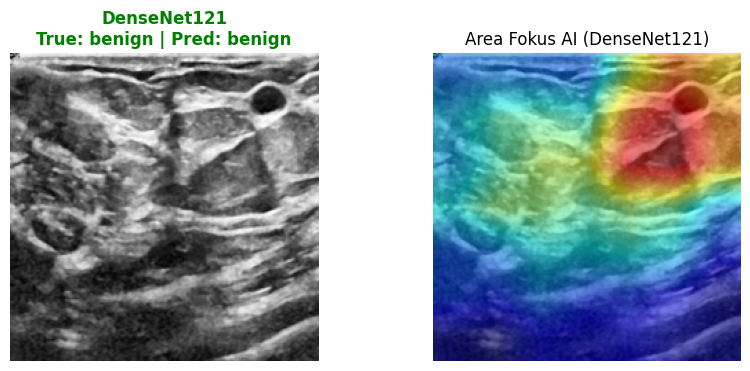

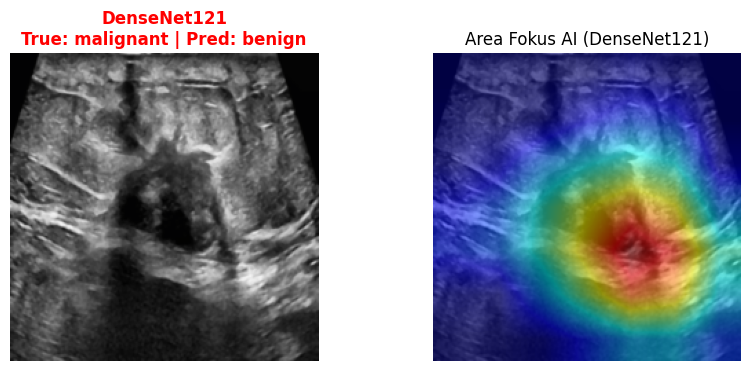

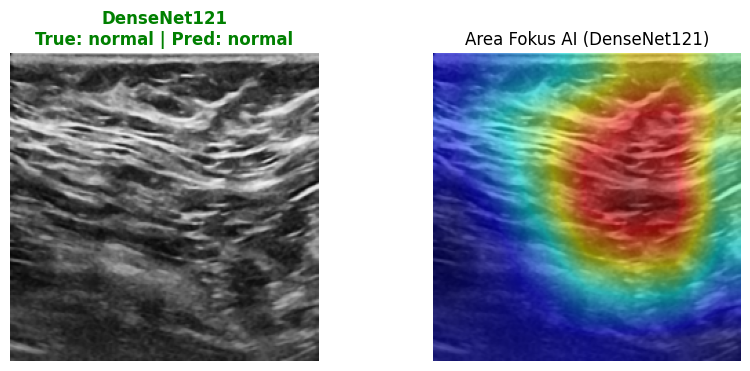


=== Visualisasi Grad-CAM: Xception ===


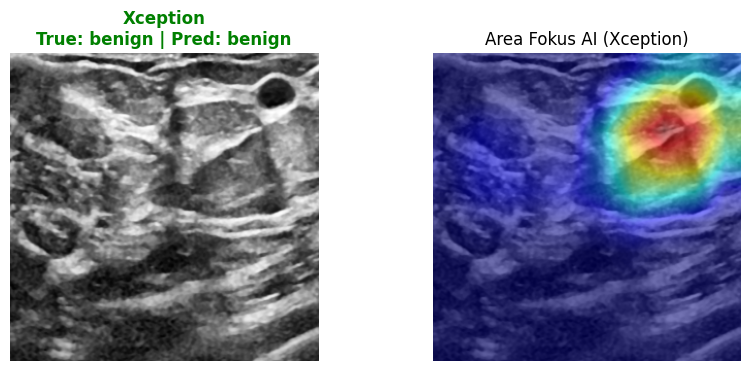

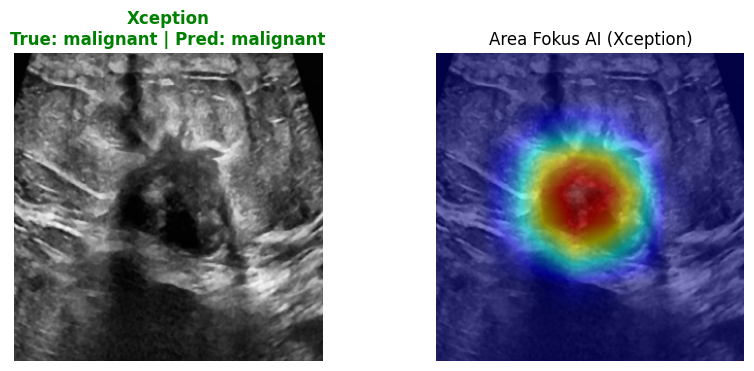

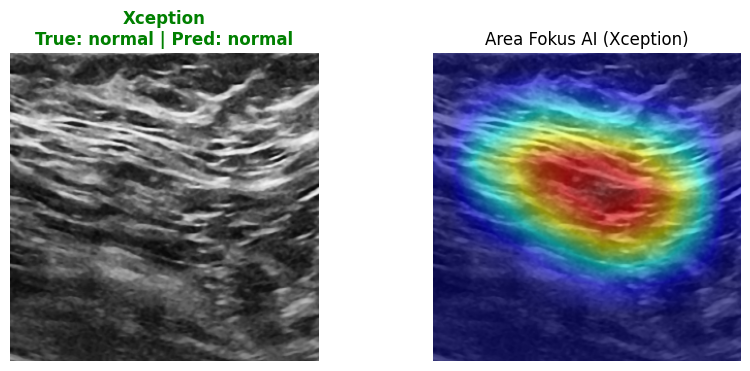

In [14]:
def evaluate_and_get_f1(model, loader, model_name):
    model.eval()
    y_true = []
    y_pred = []

    print(f"--- Menguji {model_name} pada Test Set ---")

    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    f1 = f1_score(y_true, y_pred, average='weighted')
    acc = accuracy_score(y_true, y_pred)

    print(f"Laporan Klasifikasi {model_name}:")
    print(classification_report(y_true, y_pred, target_names=train_set_dense.classes, digits=4))
    print(f"Accuracy: {acc:.4f}")
    print(f"Weighted F1-Score: {f1:.4f}\n")

    return f1, model, loader

print("\n=== PERBANDINGAN PERFORMA (F1-SCORE) ===")

model_dense = get_model('densenet', 3)
try:
    model_dense.load_state_dict(torch.load("best_densenet.pth"))
    print("Bobot DenseNet berhasil di-load.")
except:
    print("File best_densenet.pth belum ada. Pastikan training selesai.")

f1_dense, _, _ = evaluate_and_get_f1(model_dense, loader_d['test'], "DenseNet121")


model_xcp = get_model('xception', 3)
try:
    model_xcp.load_state_dict(torch.load("best_xception.pth"))
    print("Bobot Xception berhasil di-load.")
except:
    print("File best_xception.pth belum ada. Pastikan training selesai.")

f1_xcp, _, _ = evaluate_and_get_f1(model_xcp, loader_x['test'], "Xception")

print("="*40)
print(f"SKOR AKHIR:")
print(f"1. DenseNet121 : {f1_dense:.4f}")
print(f"2. Xception    : {f1_xcp:.4f}")
print("="*40)

# --- Visualisasi Grad-CAM untuk Kedua Model per Kelas ---

def visualize_gradcam_per_class(model, model_name, loader, target_layers, mean, std):
    print(f"\n=== Visualisasi Grad-CAM: {model_name} ===")
    cam = GradCAM(model=model, target_layers=target_layers)
    
    classes_to_find = list(train_set_dense.classes)
    found_counts = {c: 0 for c in classes_to_find}
    required_per_class = 1
    
    # Iterate through loader to find examples
    for images, labels in loader:
        images = images.to(device)
        
        for i in range(len(labels)):
            label_idx = labels[i].item()
            true_label = train_set_dense.classes[label_idx]
            
            # If we haven't found an example for this class yet
            if found_counts[true_label] < required_per_class:
                input_tensor = images[i].unsqueeze(0)
                
                # Prediction
                outputs = model(input_tensor)
                pred_idx = outputs.argmax(dim=1).item()
                pred_label = train_set_dense.classes[pred_idx]
                
                # Generate CAM
                targets = [ClassifierOutputTarget(pred_idx)]
                grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0, :]
                
                # Denormalize Image
                img_np = images[i].cpu().permute(1, 2, 0).numpy()
                img_rgb = (img_np * std) + mean
                img_rgb = np.clip(img_rgb, 0, 1)
                
                visualization = show_cam_on_image(img_rgb, grayscale_cam, use_rgb=True)
                
                # Plotting
                plt.figure(figsize=(10, 4))
                plt.subplot(1, 2, 1)
                plt.imshow(img_rgb)
                color = 'green' if true_label == pred_label else 'red'
                plt.title(f"{model_name}\nTrue: {true_label} | Pred: {pred_label}", color=color, fontweight='bold')
                plt.axis('off')
                
                plt.subplot(1, 2, 2)
                plt.imshow(visualization)
                plt.title(f"Area Fokus AI ({model_name})")
                plt.axis('off')
                plt.show()
                
                found_counts[true_label] += 1
        
        # Stop if all found
        if all(count >= required_per_class for count in found_counts.values()):
            break

# 1. DenseNet121
target_layer_d = [model_dense.features[-1]]
mean_d = np.array([0.485, 0.456, 0.406])
std_d = np.array([0.229, 0.224, 0.225])
visualize_gradcam_per_class(model_dense, "DenseNet121", loader_d['test'], target_layer_d, mean_d, std_d)

# 2. Xception
target_layer_x = [model_xcp.act4] if hasattr(model_xcp, 'act4') else [model_xcp.conv4]
mean_x = np.array([0.5, 0.5, 0.5])
std_x = np.array([0.5, 0.5, 0.5])
visualize_gradcam_per_class(model_xcp, "Xception", loader_x['test'], target_layer_x, mean_x, std_x)
